# 03 · 퍼셉트론에서 MLP까지

**이번 질문:** 선형 계산에 무엇을 추가하면 XOR을 풀 수 있으며, 손실의 미분을 모든 층에 어떻게 전달할까요?

[00](00_math_to_numpy.ipynb)의 행렬곱, [01](01_gradients_and_learning.ipynb)의 연쇄법칙, [02](02_probability_and_losses.ipynb)의 BCE가 준비물입니다. 노트북끼리 커널을 공유하지 않으므로 필요한 함수를 이 본문에 다시 정의합니다.

- 1–3절: 퍼셉트론·선형 분리·활성화를 손계산합니다.
- 4–6절: 다층 forward와 backward를 직접 만들고 모든 파라미터를 검산합니다.
- 7–9절: XOR 학습, 데이터 분할·L2, 직접 구조를 바꾸는 문제를 진행합니다.

[셀 실행 안내](../../README.md) · [전체 경로](../../docs/CURRICULUM.md) · [그림 보조 코드](../../src/utils/mlp_plots.py)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "utils" / "plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots, plot_gradcheck
from src import check_function
from src.utils.mlp_plots import (
    plot_activations, plot_representation, plot_regions, plot_training, plot_hidden_maps,
)
setup_plots()
np.set_printoptions(precision=5, suppress=True)
print("NumPy", np.__version__, "· 퍼셉트론과 MLP 준비 완료")

NumPy 2.3.5 · 퍼셉트론과 MLP 준비 완료


## 1. 퍼셉트론: 가중합 뒤에 판정 규칙을 둡니다

입력 $x\in\mathbb R^D$에 대해 $z=x^\top w+b$를 계산하고 $z\ge0$이면 1, 아니면 0으로 판정합니다.
2차원에서 $x_0w_0+x_1w_1+b=0$은 결정 경계인 직선입니다.

가중치 `(2,)`, 편향은 스칼라로 시작합니다. AND의 네 입력에 $w=(1,1), b=-1.5$를 넣으면 마지막 입력 `(1,1)`만 1입니다.

In [2]:
def perceptron_predict(X, w, b):
    return (X @ w + b >= 0).astype(int)


def fit_perceptron(X, y, learning_rate=1.0, epochs=30):
    w, b = np.zeros(X.shape[1]), 0.0
    mistakes_per_epoch = []
    for epoch in range(epochs):
        mistakes = 0
        for x, target in zip(X, y):
            prediction = int(x @ w + b >= 0)
            error = target - prediction
            if error != 0:
                w += learning_rate * error * x
                b += learning_rate * error
                mistakes += 1
        mistakes_per_epoch.append(mistakes)
        if mistakes == 0:
            break
    return w, b, mistakes_per_epoch

In [3]:
corners = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_and = np.array([0, 0, 0, 1])
hand_w, hand_b = np.array([1., 1.]), -1.5
np.testing.assert_array_equal(perceptron_predict(corners, hand_w, hand_b), y_and)
w_and, b_and, mistakes = fit_perceptron(corners, y_and)
np.testing.assert_array_equal(perceptron_predict(corners, w_and, b_and), y_and)
print("손으로 정한 점수", corners @ hand_w + hand_b)
print("학습한 w", w_and, "b", b_and, "· 에폭별 오분류", mistakes)

손으로 정한 점수 [-1.5 -0.5 -0.5  0.5]
학습한 w [2. 1.] b -3.0 · 에폭별 오분류 [2, 3, 3, 2, 1, 0]


위 업데이트는 오분류 여부를 사용하는 퍼셉트론 규칙입니다.
$y-\hat y=1$이면 정답 1을 놓쳤으므로 그 입력의 점수를 높이고, -1이면 낮춥니다.
한 표본을 수정한 직후 같은 입력의 점수 변화는 $\eta(y-\hat y)(\|x\|^2+1)$입니다.
계단함수는 0을 제외하면 도함수가 0이고 0에서는 미분 불가능합니다. 뒤의 신경망 학습에서는 logit과 미분 가능한 손실을 연결합니다.

## 2. XOR: 선형 분리의 한계를 수식으로 확인합니다

XOR은 두 입력이 다를 때만 1이므로 라벨은 `[0,1,1,0]`입니다.
같은 퍼셉트론으로 정확히 분류하려면 다음 네 조건이 필요합니다.

$$b<0,\quad w_1+b\ge0,\quad w_0+b\ge0,\quad w_0+w_1+b<0.$$

가운데 두 조건을 더하면 $w_0+w_1+b\ge-b>0$이 되어 마지막 조건과 모순입니다.
따라서 학습 횟수와 별개로 이 선형 판정 구조는 네 점을 모두 분류할 수 없습니다.

선형 계산만 여러 번 합성해도 같은 문제가 남습니다.

$$(XW_1+b_1)W_2+b_2=X(W_1W_2)+(b_1W_2+b_2).$$

In [4]:
Y_xor = np.array([[0.], [1.], [1.], [0.]])
rng = np.random.default_rng(303)
W1 = rng.normal(size=(2, 3))
b1 = rng.normal(size=3)
W2 = rng.normal(size=(3, 1))
b2 = rng.normal(size=1)
two_affine_layers = (corners @ W1 + b1) @ W2 + b2
collapsed_affine = corners @ (W1 @ W2) + (b1 @ W2 + b2)
np.testing.assert_allclose(two_affine_layers, collapsed_affine)
print("선형층 2개와 합친 선형층의 최대 차이:", np.max(np.abs(two_affine_layers - collapsed_affine)))

선형층 2개와 합친 선형층의 최대 차이: 2.220446049250313e-16


## 3. 활성화: 표현을 바꾸고 그 변화율도 계산합니다

활성화는 각 원소에 적용하는 비선형 함수입니다.

| 함수 | forward | 원소별 미분 |
|---|---|---|
| sigmoid | $1/(1+e^{-z})$ | $p(1-p)$ |
| tanh | $(e^z-e^{-z})/(e^z+e^{-z})$ | $1-\tanh^2z$ |
| ReLU | $\max(0,z)$ | $z>0$이면 1, $z<0$이면 0 |

ReLU의 0에서는 미분이 정의되지 않습니다. 여기서는 backward를 0으로 정하고, 중심차분 검사는 0에서 떨어진 입력을 씁니다.
은닉층에는 tanh를 사용해 처음의 역전파를 매끄러운 함수에서 확인하겠습니다.
02의 sigmoid 미분에서 tanh 미분도 연결할 수 있습니다.
$t=\tanh z=2\sigma(2z)-1$이므로 $t'=4\sigma(2z)(1-\sigma(2z))=1-t^2$입니다.

In [5]:
def sigmoid(z):
    t = np.exp(-np.abs(z))
    return np.where(z >= 0, 1 / (1+t), t / (1+t))


def activation(z, kind="tanh"):
    if kind == "tanh":
        return np.tanh(z)
    if kind == "relu":
        return np.maximum(z, 0)
    if kind == "sigmoid":
        return sigmoid(z)
    raise ValueError("알 수 없는 활성화")


def activation_derivative(z, kind="tanh"):
    if kind == "tanh":
        return 1 - np.tanh(z)**2
    if kind == "relu":
        return (z > 0).astype(float)
    if kind == "sigmoid":
        p = sigmoid(z)
        return p * (1-p)
    raise ValueError("알 수 없는 활성화")

In [6]:
activation_errors = {}
probe = np.array([-1.3, -0.2, 0.4, 1.7])
for kind in ("tanh", "relu", "sigmoid"):
    activation_errors[kind] = check_function(
        lambda z, kind=kind: activation(z, kind),
        lambda dout, z, kind=kind: dout * activation_derivative(z, kind),
        probe, verbose=True, name=kind,
    )
np.testing.assert_allclose(activation_derivative(np.array([0.]), "relu"), 0)
z_axis = np.linspace(-5, 5, 301)
activation_values = {name: activation(z_axis, name) for name in activation_errors}
derivative_values = {name: activation_derivative(z_axis, name) for name in activation_errors}

[gradcheck] tanh
  ok   dx  rel_err = 5.348e-11
[gradcheck] relu
  ok   dx  rel_err = 5.062e-11
[gradcheck] sigmoid
  ok   dx  rel_err = 1.911e-10


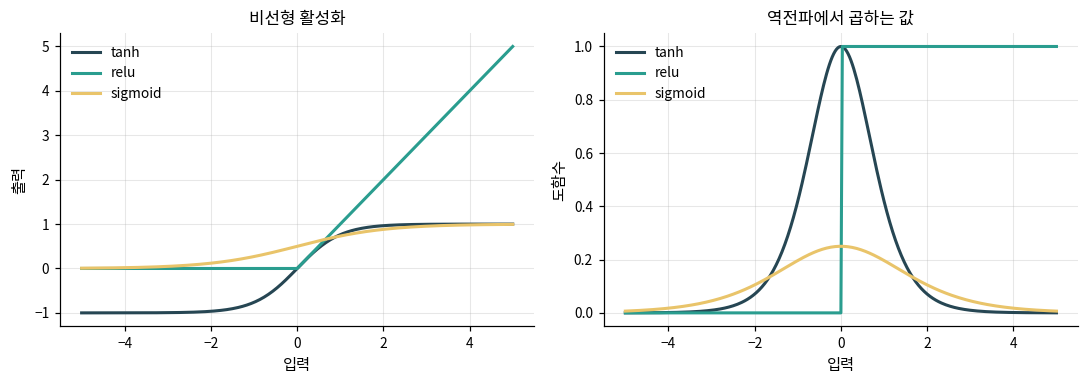

In [7]:
plot_activations(z_axis, activation_values, derivative_values)

sigmoid와 tanh의 양 끝에서는 도함수가 작습니다. 여러 층에서 작은 값을 계속 곱하면 앞쪽 기울기가 작아질 수 있습니다.
ReLU는 양수 구간의 도함수가 1이지만 음수 구간에서는 0입니다. 활성화의 출력뿐 아니라 backward에서 곱하는 값도 함께 봅니다.

### 손으로 만든 은닉층으로 XOR 풀기

$s=x_0+x_1$, $h_0=\operatorname{ReLU}(s)$, $h_1=\operatorname{ReLU}(s-1)$로 놓습니다.
네 입력에서 $h_0-2h_1$은 `0,1,1,0`이 됩니다.
마지막 logit을 $z=10(h_0-2h_1-0.5)$로 두면 부호로 XOR을 구분할 수 있습니다.

In [8]:
hand_W1 = np.array([[1., 1.], [1., 1.]])
hand_b1 = np.array([0., -1.])
hand_hidden = activation(corners @ hand_W1 + hand_b1, "relu")
hand_logits = hand_hidden @ np.array([[10.], [-20.]]) - 5
np.testing.assert_allclose(hand_hidden, [[0,0], [1,0], [1,0], [2,1]])
np.testing.assert_array_equal((hand_logits >= 0).astype(float), Y_xor)
print("은닉 표현:\n", hand_hidden)
print("최종 logit:", hand_logits.ravel())

은닉 표현:
 [[0. 0.]
 [1. 0.]
 [1. 0.]
 [2. 1.]]
최종 logit: [-5.  5.  5. -5.]


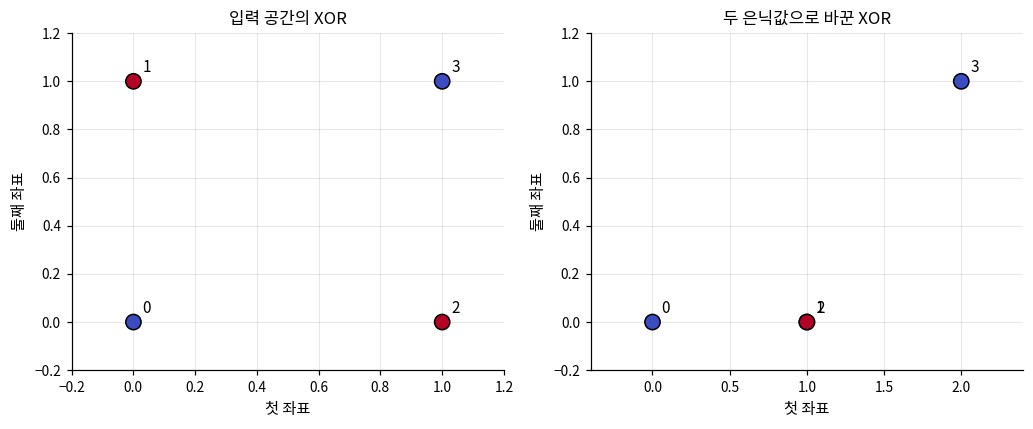

In [9]:
plot_representation(corners, hand_hidden, Y_xor)

입력에서 한 직선으로 나눌 수 없었던 점들이 은닉 표현에서는 선형 판정 가능한 위치로 바뀝니다.
1번과 2번 점은 같은 은닉 좌표에 겹칩니다. 이 예제는 가중치를 손으로 정했고, 이제 손실에서 같은 종류의 구조를 학습시키겠습니다.

## 4. MLP forward: 층마다 같은 규칙을 적용합니다

MLP는 다층 퍼셉트론(multilayer perceptron)입니다. 여기서는 마지막 층만 활성화 없이 logit을 출력합니다.

$$A_0=X,\quad Z_\ell=A_{\ell-1}W_\ell+b_\ell,\quad
A_\ell=\tanh(Z_\ell)\ (\ell<L),\quad Z_L=\text{logits}.$$

| 이름 | 일반 shape | 2 → 4 → 1 예제 |
|---|---|---|
| $A_{\ell-1}$ | `(N, d_in)` | 첫 층 입력 `(N,2)` |
| $W_\ell,b_\ell$ | `(d_in,d_out)`, `(d_out,)` | `(2,4)`, `(4,)` |
| $Z_\ell,A_\ell$ | `(N,d_out)` | 은닉값 `(N,4)` |
| 최종 logit | `(N,1)` | 이진 분류의 점수 |

파라미터는 `[{'W': ..., 'b': ...}, ...]` 형태의 목록입니다. `sizes=[2,4,1]`은 각 층의 너비이며 이웃한 크기 쌍으로 가중치를 만듭니다.
초기 가중치는 서로 다른 난수로 정합니다. 모든 은닉 유닛을 같은 값으로 시작하면 같은 역할에서 벗어나지 못할 수 있습니다.
여기서는 tanh를 위해 표준편차 $\sqrt{2/(d_{in}+d_{out})}$인 Glorot 정규 초기화를 사용하고, 04에서 크기의 영향을 직접 실험합니다.

In [10]:
def init_mlp(sizes, seed=0):
    rng = np.random.default_rng(seed)
    return [{"W": rng.normal(size=(din, dout)) * np.sqrt(2 / (din + dout)),
             "b": np.zeros(dout)}
            for din, dout in zip(sizes[:-1], sizes[1:])]


def mlp_forward(X, parameters, hidden_activation="tanh"):
    A = X
    caches = []
    for layer_index, layer in enumerate(parameters):
        Z = A @ layer["W"] + layer["b"]
        caches.append((A, Z))
        last = layer_index == len(parameters) - 1
        A = Z if last else activation(Z, hidden_activation)
    return A, caches

In [11]:
small_parameters = [
    {"W": np.array([[1., -1.], [0.5, 2.]]), "b": np.array([0.1, -0.2])},
    {"W": np.array([[0.3], [-0.4]]), "b": np.array([0.2])},
]
small_X = np.array([[1., 2.]])
small_logits, small_cache = mlp_forward(small_X, small_parameters)
# 첫 층은 [1*1+2*0.5+0.1, 1*(-1)+2*2-0.2] = [2.1,2.8]
manual_hidden = np.tanh(np.array([2.1, 2.8]))
manual_logit = 0.3 * manual_hidden[0] - 0.4 * manual_hidden[1] + 0.2
np.testing.assert_allclose(small_cache[0][1], [[2.1, 2.8]])
np.testing.assert_allclose(small_logits, [[manual_logit]])
print("첫 층 Z", small_cache[0][1], "· 은닉 A", manual_hidden, "· 최종 logit", small_logits)
for layer, (A, Z) in zip(small_parameters, small_cache):
    print("A", A.shape, "W", layer["W"].shape, "b", layer["b"].shape, "Z", Z.shape)

첫 층 Z [[2.1 2.8]] · 은닉 A [0.97045 0.99263] · 최종 logit [[0.09408]]
A (1, 2) W (2, 2) b (2,) Z (1, 2)
A (1, 2) W (2, 1) b (1,) Z (1, 1)


캐시(cache)는 forward 때 계산한 입력 A와 활성화 전 값 Z를 backward에서 다시 쓰려고 보관한 것입니다.
파라미터는 forward·backward 계산이 끝난 뒤 갱신합니다. 중간에 W를 바꾸면 다른 파라미터에서 계산한 기울기를 섞게 됩니다.

## 5. backward: 손실에서 출발해 같은 길을 거꾸로 갑니다

BCE의 최종 logit 기울기는 $D_L=(\sigma(Z_L)-Y)/N$입니다. 여기서는 출력이 하나입니다.
각 층에서 다음 세 식을 계산합니다.

$$\frac{\partial J}{\partial W_\ell}=A_{\ell-1}^\top D_\ell,\quad
\frac{\partial J}{\partial b_\ell}=\sum_n D_{\ell,n},\quad
\frac{\partial J}{\partial A_{\ell-1}}=D_\ell W_\ell^\top.$$

앞이 은닉층이면 $D_{\ell-1}=(D_\ell W_\ell^\top)\odot(1-\tanh^2 Z_{\ell-1})$입니다.
$\odot$는 원소별 곱입니다. 입력 X까지 기울기를 전달하면 01의 affine backward와 연결됩니다.

예를 들어 $\partial J/\partial W_{dk}=\sum_n A_{nd}D_{nk}$입니다. 모든 샘플에서 **같은 W를 공유**하므로 사용된 자리의 기여를 합합니다. 같은 파라미터가 다른 위치나 시간에 반복 사용될 때도 이 원리가 CNN·RNN으로 이어집니다.

In [12]:
def bce_with_logits(logits, targets):
    assert logits.shape == targets.shape
    loss = np.mean(np.logaddexp(0, logits) - targets * logits)
    return float(loss), (sigmoid(logits) - targets) / targets.size


def mlp_backward(dlogits, parameters, caches, hidden_activation="tanh"):
    gradients = [None] * len(parameters)
    dZ = dlogits
    for index in range(len(parameters) - 1, -1, -1):
        A_previous, Z = caches[index]
        W = parameters[index]["W"]
        gradients[index] = {"W": A_previous.T @ dZ, "b": dZ.sum(axis=0)}
        dA_previous = dZ @ W.T
        if index == 0:
            dX = dA_previous
        else:
            previous_Z = caches[index - 1][1]
            dZ = dA_previous * activation_derivative(previous_Z, hidden_activation)
    return dX, gradients


def mlp_loss_and_gradients(X, Y, parameters, l2=0.0, backward_fn=mlp_backward):
    logits, caches = mlp_forward(X, parameters)
    data_loss, dlogits = bce_with_logits(logits, Y)
    dX, gradients = backward_fn(dlogits, parameters, caches)
    penalty = 0.0
    for layer, gradient in zip(parameters, gradients):
        penalty += 0.5 * l2 * np.sum(layer["W"]**2)
        gradient["W"] += l2 * layer["W"]
    return data_loss + penalty, dX, gradients

`l2=0`에서는 위의 BCE만 사용합니다. `l2`가 양수인 경우의 목적과 미분은 8절에서 설명하고 검산합니다.
`gradients`는 파라미터와 같은 순서·같은 키·같은 shape입니다. 업데이트는 이 기울기를 계산한 다음 별도 단계에서 수행합니다.

## 6. 모든 가중치·편향·입력의 기울기를 검산합니다

손으로 유도한 backward와, 파라미터 원소를 $\pm\epsilon$ 바꾸어 forward만 재계산하는 중심차분을 대조합니다.
`check_function`의 forward는 스칼라 손실을 반환하고, `dout=1`을 전달하므로 같은 손실을 직접 미분합니다.
`index`와 `key`로 검사할 배열 하나를 선택하고 나머지 파라미터는 그대로 둡니다.

In [13]:
def check_mlp_gradients(X, Y, parameters, l2=0.0, backward_fn=mlp_backward):
    errors = {}
    for index, layer in enumerate(parameters):
        for key in ("W", "b"):
            def changed(value, index=index, key=key):
                copy = [dict(item) for item in parameters]
                copy[index][key] = value
                return copy

            def forward(value):
                return np.array(mlp_loss_and_gradients(X, Y, changed(value), l2, backward_fn)[0])

            def backward(dout, value, index=index, key=key):
                grads = mlp_loss_and_gradients(X, Y, changed(value), l2, backward_fn)[2]
                return dout * grads[index][key]

            name = f"{key}{index+1}"
            errors[name] = check_function(forward, backward, layer[key], dout=np.array(1.),
                                           tol=2e-6, verbose=True, name=name)
    errors["X"] = check_function(
        lambda x: np.array(mlp_loss_and_gradients(x, Y, parameters, l2, backward_fn)[0]),
        lambda dout, x: dout * mlp_loss_and_gradients(x, Y, parameters, l2, backward_fn)[1],
        X, dout=np.array(1.), tol=2e-6, verbose=True, name="X",
    )
    return errors

In [14]:
check_X = np.array([[-0.7, 0.2], [0.4, -0.8], [0.6, 0.5]])
check_Y = np.array([[0.], [1.], [0.]])
check_parameters = init_mlp([2, 3, 2, 1], seed=17)
network_errors = check_mlp_gradients(check_X, check_Y, check_parameters)
print("네트워크 최대 상대오차", max(network_errors.values()))

[gradcheck] W1
  ok   dx  rel_err = 1.399e-10
[gradcheck] b1
  ok   dx  rel_err = 1.478e-10
[gradcheck] W2
  ok   dx  rel_err = 2.647e-10
[gradcheck] b2
  ok   dx  rel_err = 2.829e-10
[gradcheck] W3
  ok   dx  rel_err = 3.370e-10
[gradcheck] b3
  ok   dx  rel_err = 6.154e-11
[gradcheck] X
  ok   dx  rel_err = 4.981e-10
네트워크 최대 상대오차 4.98115205884979e-10


<Axes: ylabel='상대오차'>

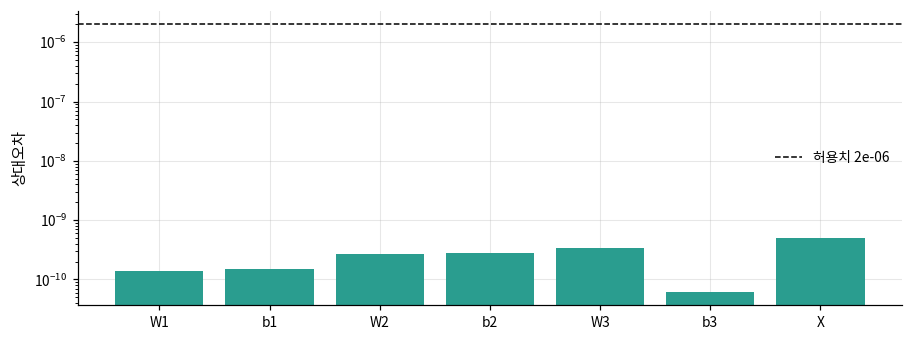

In [15]:
plot_gradcheck(network_errors, tol=2e-6)

샘플을 두 번 복제하면 평균 손실과 공유 파라미터의 기울기는 같습니다. 입력 각 복제본의 기울기는 평균의 분모 때문에 절반으로 줄어듭니다. 수치미분과는 다른 성질로 평균·합하는 축을 한 번 더 점검합니다.

In [16]:
loss_one, dX_one, grad_one = mlp_loss_and_gradients(check_X, check_Y, check_parameters)
loss_twice, dX_twice, grad_twice = mlp_loss_and_gradients(
    np.concatenate([check_X, check_X]), np.concatenate([check_Y, check_Y]), check_parameters)
np.testing.assert_allclose(loss_twice, loss_one)
np.testing.assert_allclose(dX_twice[:len(check_X)], dX_one / 2)
for single, doubled in zip(grad_one, grad_twice):
    for key in ("W", "b"):
        np.testing.assert_allclose(single[key], doubled[key])
print("배치 복제: 손실·공유 파라미터 기울기·입력 기울기 관계 통과")

배치 복제: 손실·공유 파라미터 기울기·입력 기울기 관계 통과


## 7. XOR을 실제로 학습시킵니다

두 모델 모두 같은 BCE, 같은 데이터, 같은 갱신 규칙을 사용합니다. `[2,1]`은 선형 logit이고 `[2,4,1]`은 tanh 은닉층을 가진 MLP입니다.
`fit_mlp`는 시작 파라미터를 복사하므로 비교 실험끼리 배열을 공유하지 않습니다. 기록은 갱신 전 0회부터 갱신 후 마지막까지 저장합니다.

In [17]:
def fit_mlp(X, Y, initial_parameters, steps=2500, learning_rate=0.2, l2=0.0,
            validation=None):
    parameters = [{key: value.copy() for key, value in layer.items()} for layer in initial_parameters]
    history = {"objective": [], "train_bce": [], "validation_bce": []}
    for step in range(steps + 1):
        objective, _, gradients = mlp_loss_and_gradients(X, Y, parameters, l2)
        logits, _ = mlp_forward(X, parameters)
        history["objective"].append(objective)
        history["train_bce"].append(bce_with_logits(logits, Y)[0])
        if validation is not None:
            val_X, val_Y = validation
            val_logits, _ = mlp_forward(val_X, parameters)
            history["validation_bce"].append(bce_with_logits(val_logits, val_Y)[0])
        if step == steps:
            break
        for layer, gradient in zip(parameters, gradients):
            layer["W"] -= learning_rate * gradient["W"]
            layer["b"] -= learning_rate * gradient["b"]
    return parameters, history

In [18]:
linear_model, linear_history = fit_mlp(corners, Y_xor, init_mlp([2, 1], seed=4))
mlp_model, mlp_history = fit_mlp(corners, Y_xor, init_mlp([2, 4, 1], seed=4))
linear_logits, _ = mlp_forward(corners, linear_model)
mlp_logits, mlp_caches = mlp_forward(corners, mlp_model)
mlp_accuracy = np.mean((mlp_logits >= 0) == Y_xor)
assert mlp_accuracy == 1.0 and mlp_history["train_bce"][-1] < 0.03
np.testing.assert_allclose(linear_history["train_bce"][-1], np.log(2), atol=1e-5)
print(f"선형 BCE {linear_history['train_bce'][-1]:.6f}")
print(f"MLP BCE {mlp_history['train_bce'][0]:.6f} → {mlp_history['train_bce'][-1]:.6f}")
print("MLP의 XOR 확률", sigmoid(mlp_logits).ravel(), "· 정확도", mlp_accuracy)

선형 BCE 0.693147
MLP BCE 0.759459 → 0.003789
MLP의 XOR 확률 [0.00121 0.99574 0.99584 0.0055 ] · 정확도 1.0


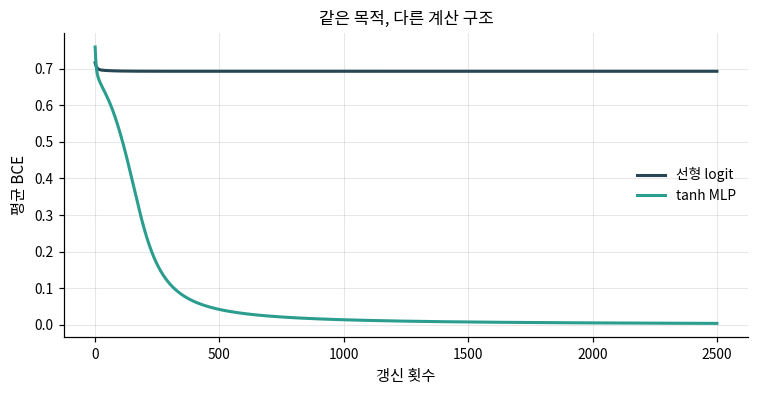

In [19]:
plot_training({"선형 logit": linear_history["train_bce"], "tanh MLP": mlp_history["train_bce"]})

선형 모델의 손실은 이 대칭적인 네 점에서 약 $\log2$로 수렴했습니다. 분리가 불가능하다는 근거는 앞의 네 부등식이며, 이 학습 결과는 그 한 사례입니다.
MLP는 같은 BCE를 사용하면서도 은닉 표현을 바꿀 수 있습니다. 손실과 모델 구조가 담당하는 역할을 구분해 볼 수 있습니다.

격자 그림에서는 00처럼 `meshgrid → ravel → column_stack`으로 점을 만듭니다.
`xx`, `yy`는 `(100,100)`, `grid`는 `(10000,2)`, 예측 확률은 `(10000,1)`입니다. 그림용으로 다시 `(100,100)`으로 바꿉니다.

In [20]:
xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 100), np.linspace(-0.4, 1.4, 100))
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_logits, grid_caches = mlp_forward(grid, mlp_model)
grid_probability = sigmoid(grid_logits).reshape(xx.shape)
hidden_grid = activation(grid_caches[0][1]).reshape(*xx.shape, 4)

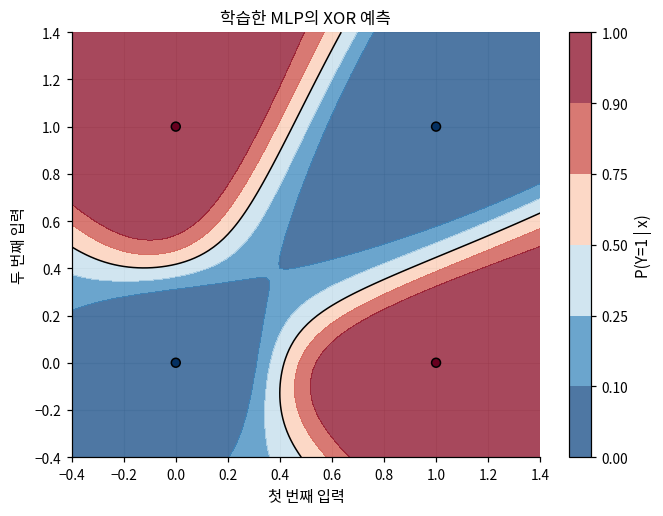

In [21]:
plot_regions(xx, yy, grid_probability, corners, Y_xor, "학습한 MLP의 XOR 예측")

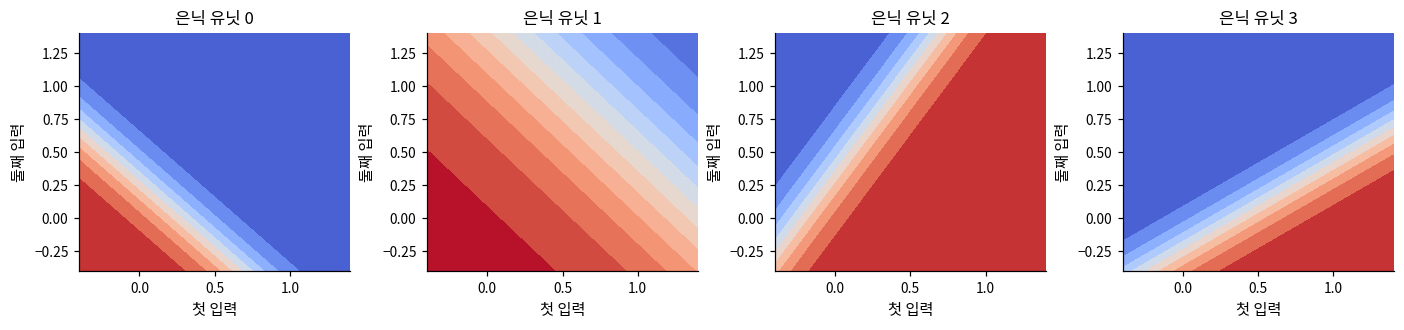

In [22]:
plot_hidden_maps(xx, yy, hidden_grid)

은닉 유닛마다 입력의 다른 부분에서 값이 달라지고, 마지막 선형층이 이 네 값을 조합해 logit을 만듭니다.
격자의 색은 네 학습점 사이와 바깥에서 **현재 모델이 하는 예측**입니다. 그 영역의 정답을 검증한 그림은 아닙니다.

## 8. 새 데이터에서 확인하기: 분할과 L2

학습에 사용하지 않은 표본의 BCE를 따로 계산합니다. 예제는 네 모서리 주변에 잡음을 더한 작은 XOR 분포입니다.
학습·검증 데이터를 서로 다른 난수로 생성하며, 검증 데이터는 파라미터 업데이트에 넣지 않습니다.

L2를 적용하면 목적은 다음과 같습니다.

$$J=\underbrace{\frac1N\sum_n\ell_n}_{\text{평균 BCE}}+
\underbrace{\frac\lambda2\sum_\ell\|W_\ell\|_F^2}_{\text{가중치 제곱합 페널티}}.$$

$\|W\|_F^2=\sum_{d,k}W_{dk}^2$이며 미분에는 $\lambda W$를 더합니다. 여기서는 편향에 페널티를 주지 않습니다.
이미 평균낸 BCE에 페널티를 더하므로 **페널티를 N으로 다시 나누지 않습니다.** 다른 정의를 쓰면 $\lambda$의 의미도 달라집니다.
그림에서는 두 모델을 공정하게 읽도록 페널티를 제외한 BCE를 비교하고, 업데이트는 각각 정의한 목적을 사용합니다.

In [23]:
def sample_noisy_xor(samples_per_corner, seed):
    rng = np.random.default_rng(seed)
    X = np.repeat(corners, samples_per_corner, axis=0)
    X = X + rng.normal(0, 0.22, size=X.shape)
    Y = np.repeat(Y_xor, samples_per_corner, axis=0)
    order = rng.permutation(len(X))
    return X[order], Y[order]

In [24]:
regularized_errors = check_mlp_gradients(check_X, check_Y, check_parameters, l2=0.03)
train_X, train_Y = sample_noisy_xor(12, seed=10)
val_X, val_Y = sample_noisy_xor(80, seed=11)
shared_initial = init_mlp([2, 8, 1], seed=5)
regularization_results = {}
for strength in (0.0, 0.01):
    model, history = fit_mlp(train_X, train_Y, shared_initial, steps=1800,
                             learning_rate=0.15, l2=strength, validation=(val_X, val_Y))
    regularization_results[strength] = (model, history)
    print(f"λ={strength}: train BCE={history['train_bce'][-1]:.4f}, "
          f"validation BCE={history['validation_bce'][-1]:.4f}")
np.testing.assert_allclose(shared_initial[0]["b"], 0)

[gradcheck] W1
  ok   dx  rel_err = 1.437e-10
[gradcheck] b1
  ok   dx  rel_err = 1.947e-10
[gradcheck] W2
  ok   dx  rel_err = 2.404e-10
[gradcheck] b2
  ok   dx  rel_err = 2.829e-10
[gradcheck] W3
  ok   dx  rel_err = 2.303e-10
[gradcheck] b3
  ok   dx  rel_err = 4.570e-10
[gradcheck] X
  ok   dx  rel_err = 5.531e-10


λ=0.0: train BCE=0.0166, validation BCE=0.0985


λ=0.01: train BCE=0.1399, validation BCE=0.1908


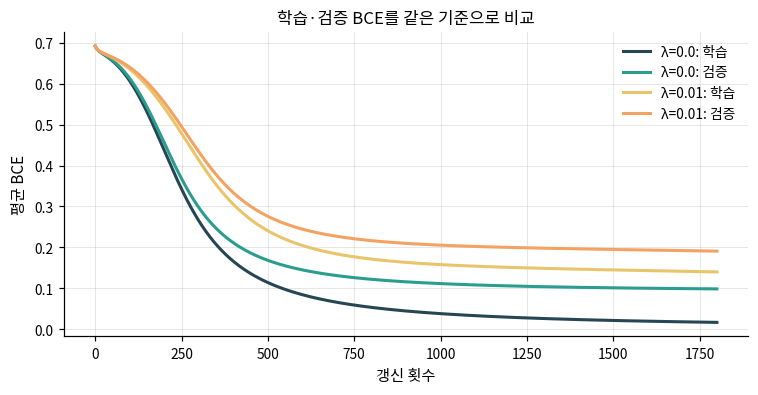

In [25]:
comparison = {}
for strength, (_, history) in regularization_results.items():
    comparison[f"λ={strength}: 학습"] = history["train_bce"]
    comparison[f"λ={strength}: 검증"] = history["validation_bce"]
plot_training(comparison, title="학습·검증 BCE를 같은 기준으로 비교")

L2가 검증 성능을 항상 높이는 것은 아닙니다. 위 숫자는 이 데이터·시드·학습 설정에서의 관측값입니다.
검증 결과로 설정을 고르기 시작하면 그 검증셋도 선택 과정에 사용됩니다. 최종 일반화 성능을 보고하려면 선택에 사용하지 않은 테스트셋을 따로 둡니다. 여기서는 분할과 목적의 차이를 확인하는 실험까지만 합니다.

## 9. 직접 바꾸고 복원합니다

### 연습 A · 활성화 미분 바꾸기

Leaky ReLU를 $f(z)=z$ (z>0), $f(z)=\alpha z$ (z<0)로 정의합니다. $\alpha=0.1$일 때
원소별 도함수를 반환하는 `my_leaky_derivative(z)`를 직접 작성하세요.
새 Code 셀에 정의한 뒤 `check_leaky_derivative(my_leaky_derivative)`을 실행합니다.

In [26]:
def leaky_derivative_example(z):
    return np.where(z > 0, 1.0, 0.1)


def check_leaky_derivative(candidate):
    z = np.array([-2., -0.3, 0.2, 1.5])
    np.testing.assert_allclose(candidate(z), [0.1, 0.1, 1., 1.])
    check_function(lambda v: np.where(v > 0, v, 0.1*v),
                   lambda dout, v: dout * candidate(v), z, verbose=True, name="Leaky ReLU")
    print("직접 만든 도함수가 손계산·중심차분과 일치합니다.")

In [27]:
check_leaky_derivative(leaky_derivative_example)

[gradcheck] Leaky ReLU
  ok   dx  rel_err = 3.606e-11
직접 만든 도함수가 손계산·중심차분과 일치합니다.


### 연습 B · 은닉층의 너비 바꾸기

`[2,3,2,1]`을 `[2,5,3,1]`로 바꾸면 어떤 W와 b의 shape가 생기는지 먼저 적으세요.
forward·backward의 식은 같고, 목록의 크기만 달라져야 합니다.
아래 완성 예제를 확인한 뒤 다른 너비로 바꾸어 **학습 전에** 기울기를 검산하세요.

In [28]:
changed_parameters = init_mlp([2, 5, 3, 1], seed=23)
expected_shapes = [((2,5), (5,)), ((5,3), (3,)), ((3,1), (1,))]
for layer, (w_shape, b_shape) in zip(changed_parameters, expected_shapes):
    assert layer["W"].shape == w_shape and layer["b"].shape == b_shape
changed_errors = check_mlp_gradients(check_X, check_Y, changed_parameters)
print("구조 변형의 최대 상대오차", max(changed_errors.values()))

[gradcheck] W1
  ok   dx  rel_err = 5.696e-10
[gradcheck] b1
  ok   dx  rel_err = 9.753e-10
[gradcheck] W2
  ok   dx  rel_err = 4.583e-10
[gradcheck] b2
  ok   dx  rel_err = 3.263e-10
[gradcheck] W3
  ok   dx  rel_err = 1.482e-09
[gradcheck] b3
  ok   dx  rel_err = 4.005e-10
[gradcheck] X
  ok   dx  rel_err = 2.564e-09
구조 변형의 최대 상대오차 2.5641789882291924e-09


### 연습 C · backward를 직접 다시 쓰기

5절을 가리고 `my_backward(dlogits, parameters, caches)`를 작성해 보세요.
아래는 MLP를 **선형층 하나로 줄인 경우**의 손계산을 검사합니다. 작은 경우를 통과한 다음 6절의 여러 층 수치미분 검사로 확장합니다.
함수는 `(dX, gradients)`를 반환하고 `gradients`의 각 항목에는 W·b 기울기가 있어야 합니다.
단층 검사를 통과한 다음 새 Code 셀에서 다음을 실행하면 **직접 쓴 함수**를 여러 층에서 검사합니다.

```python
check_mlp_gradients(check_X, check_Y, check_parameters, backward_fn=my_backward)
```

`backward_fn`은 검사할 함수를 받는 인자입니다. 생략하면 본문의 `mlp_backward`를 검사합니다.
단층에는 tanh가 없으므로 단층 검사만으로 은닉층의 미분이 맞는지 판정할 수 없습니다.

In [29]:
def check_single_layer_backward(candidate):
    X = np.array([[1., 2.], [-1., 1.]])
    parameters = [{"W": np.array([[2.], [3.]]), "b": np.array([0.5])}]
    _, caches = mlp_forward(X, parameters)
    dout = np.array([[0.2], [-0.4]])
    dX, gradients = candidate(dout, parameters, caches)
    np.testing.assert_allclose(dX, [[0.4, 0.6], [-0.8, -1.2]])
    np.testing.assert_allclose(gradients[0]["W"], [[0.6], [0.] ], atol=1e-15)
    np.testing.assert_allclose(gradients[0]["b"], [-0.2])
    print("직접 쓴 backward의 입력·공유 가중치·편향 기울기가 일치합니다.")

In [30]:
check_single_layer_backward(mlp_backward)

직접 쓴 backward의 입력·공유 가중치·편향 기울기가 일치합니다.


### 다음으로 가기 전, 네 가지를 따로 확인합니다

- **설명:** XOR의 네 부등식으로 선형 판정의 한계를 보이고 은닉층이 바꾸는 것을 말할 수 있나요? → 2·3절
- **수식:** 한 은닉층을 거꾸로 통과할 때 행렬곱과 원소별 곱을 구분해 쓸 수 있나요? → 5절
- **구현:** 캐시에 무엇을 남길지 정하고, 모든 W·b·X의 미분을 검산했나요? → 4–6절
- **변형:** 층 너비·깊이·활성화·L2를 바꾸면 어느 식과 어느 검산이 바뀌나요? → 8·9절

다음은 [04 · optimizer의 계산](04_optimizers.ipynb)입니다. 검산한 기울기를 받은 뒤 파라미터를 갱신하는 방식을 바꿉니다.

참고: [D2L MLP](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html), [Glorot·Bengio의 초기화 논문](https://proceedings.mlr.press/v9/glorot10a.html). 그림·기울기·학습 결과는 본문에서 계산합니다.